# 🖥️ Laptop Dataset — End-to-End Preprocessing Notebook

**Dataset columns:**
`Company, TypeName, Inches, Weight, screen_resolution, display_type, processor_speed,
processor_brand, processor_type, ssd_storage, hdd_storage, flash_storage, ram, os,
Price, has_ssd, cpu_bin`

**Preprocessing pipeline:**
1. Import Libraries  
2. Load & Inspect Data  
3. Handle Missing Values  
4. Fix Data Types  
5. Outlier Detection & Treatment  
6. Feature Engineering  
7. Encoding (Label + One-Hot)  
8. Feature Scaling  
9. Feature Selection  
10. Train/Test Split  
11. Final Summary & Export


## 1. 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn preprocessing
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
)
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression
)
from sklearn.impute import SimpleImputer

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.facecolor'] = '#F8FAFC'
plt.rcParams['axes.facecolor']   = '#F8FAFC'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


## 2. 📂 Load & Inspect Data

In [2]:
# load the data
df = pd.read_csv("laptop_clean_dataset.csv")
print("✅ Dataset loaded")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


✅ Dataset loaded
   Shape: 1243 rows × 15 columns


,Company,TypeName,Inches,Weight,screen_resolution,display_type,processor_speed,processor_brand,processor_type,ssd_storage,hdd_storage,flash_storage,ram,os,Price
0,Apple,Ultrabook,13.30,1.37,2560x1600,Quad HD,2.30,Intel,Core i5,128,0,0,8,macos,71378.68
1,Apple,Ultrabook,13.30,1.34,1440x900,HD,1.80,Intel,Core i5,0,0,128,8,macos,47895.52
2,HP,Notebook,15.60,1.86,1920x1080,Full HD,2.50,Intel,Core i5 7200U,256,0,0,8,no,30636.00
3,Apple,Ultrabook,15.40,1.83,2880x1800,Quad HD,2.70,Intel,Core i7,512,0,0,16,macos,135195.34
4,Apple,Ultrabook,13.30,1.37,2560x1600,Quad HD,3.10,Intel,Core i5,256,0,0,8,macos,96095.81


In [3]:
# Basic info
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1243 entries, 0 to 1242
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            1243 non-null   str    
 1   TypeName           1243 non-null   str    
 2   Inches             1243 non-null   float64
 3   Weight             1243 non-null   str    
 4   screen_resolution  1243 non-null   str    
 5   display_type       1243 non-null   str    
 6   processor_speed    1243 non-null   float64
 7   processor_brand    1243 non-null   str    
 8   processor_type     1243 non-null   str    
 9   ssd_storage        1243 non-null   int64  
 10  hdd_storage        1243 non-null   str    
 11  flash_storage      1243 non-null   int64  
 12  ram                1243 non-null   int64  
 13  os                 1243 non-null   str    
 14  Price              1243 non-null   float64
dtypes: float64(3), int64(3), str(9)
memory usage: 145.8 KB


In [4]:
# Descriptive statistics — numeric columns
print("NUMERIC DESCRIPTIVE STATISTICS")
df.describe().round(2)


NUMERIC DESCRIPTIVE STATISTICS


,Inches,processor_speed,ssd_storage,flash_storage,ram,Price
count,1243.00,1243.00,1243.00,1243.00,1243.00,1243.00
mean,15.01,2.30,172.79,4.49,8.45,60631.45
std,1.45,0.50,161.33,30.77,5.12,37429.12
min,9.45,0.90,0.00,0.00,2.00,9270.72
25%,14.00,2.00,0.00,0.00,4.00,32687.28
50%,15.60,2.50,180.00,0.00,8.00,52693.92
75%,15.60,2.70,256.00,0.00,8.00,79813.44
max,18.40,3.60,512.00,512.00,64.00,324954.72


In [5]:
# Descriptive statistics — categorical columns
cat_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print()
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique | top-5: {df[col].value_counts().head(5).to_dict()}")


Categorical columns (9): ['Company', 'TypeName', 'Weight', 'screen_resolution', 'display_type', 'processor_brand', 'processor_type', 'hdd_storage', 'os']

  Company: 18 unique | top-5: {'Dell': 281, 'Lenovo': 281, 'HP': 260, 'Asus': 149, 'Acer': 105}
  TypeName: 5 unique | top-5: {'Notebook': 711, 'Gaming': 203, 'Ultrabook': 189, '2 in 1 Convertible': 111, 'Workstation': 29}
  Weight: 184 unique | top-5: {'2.2': 108, '2.1': 58, '2.4': 41, '2.5': 37, '2.3': 37}
  screen_resolution: 15 unique | top-5: {'1920x1080': 814, '1366x768': 282, '3840x2160': 42, '3200x1800': 24, '1600x900': 23}
  display_type: 4 unique | top-5: {'Full HD': 835, 'HD': 309, 'Quad HD': 57, '4K': 42}
  processor_brand: 3 unique | top-5: {'Intel': 1182, 'AMD': 60, 'Samsung': 1}
  processor_type: 93 unique | top-5: {' Core i5 7200U': 186, ' Core i7 7700HQ': 143, ' Core i7 7500U': 127, ' Core i3 6006U': 79, ' Core i7 8550U': 72}
  hdd_storage: 8 unique | top-5: {'0': 695, '1TB': 390, '500': 123, '2TB': 31, '1TB 1TB': 1}

## 3. 🔍 Missing Value Analysis & Treatment

We check missing percentage per column, visualize it, then apply appropriate strategy:
- **Numeric** → median imputation (robust to outliers)
- **Categorical** → mode imputation
- Drop columns with > 50% missing


In [8]:
# convert 1TB = 1024GB for display purposes
df['hdd_storage'] = df['hdd_storage'].str.replace('1TB', '1024').str.replace('2TB', '2048').str.replace('1024 1024', '1024').str.replace('0TB','0').astype(int)

In [16]:
df[df['hdd_storage'] == '0']

,Company,TypeName,Inches,Weight,screen_resolution,display_type,processor_speed,processor_brand,processor_type,ssd_storage,hdd_storage,flash_storage,ram,os,Price


In [10]:
df[df["Weight"] == '?']

,Company,TypeName,Inches,Weight,screen_resolution,display_type,processor_speed,processor_brand,processor_type,ssd_storage,hdd_storage,flash_storage,ram,os,Price
201,Dell,Ultrabook,13.30,?,1920x1080,Full HD,1.80,Intel,Core i7 8550U,256,0,0,8,windows,77202.72


In [12]:
df['Weight'] = df['Weight'].str.replace('?','0').astype(float)

In [13]:
# convert weight column dtype
df['Weight'] = df['Weight'].astype(float)

In [14]:
# ── Missing value summary
miss = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("MISSING VALUE REPORT")
print("=" * 40)
print(miss.to_string())


MISSING VALUE REPORT
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


ValueError: zero-size array to reduction operation fmin which has no identity

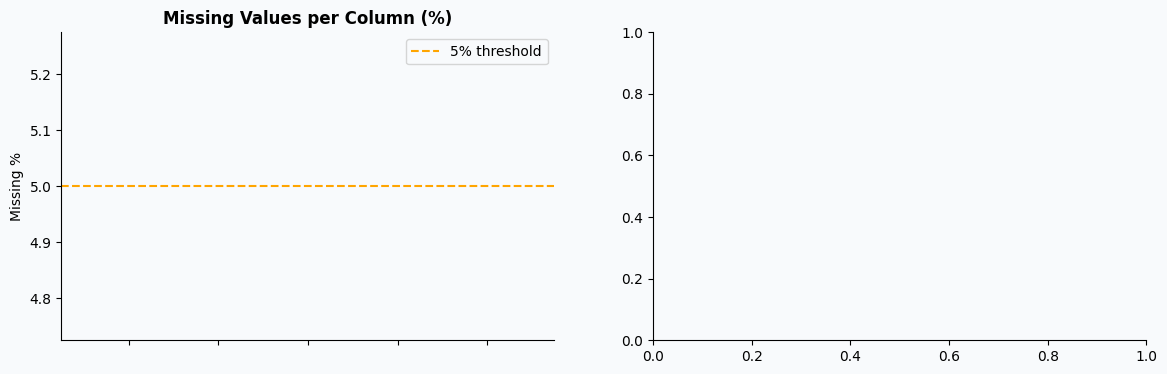

In [7]:
# ── Visualise missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]
axes[0].bar(miss_pct.index, miss_pct.values, color='#DC2626', edgecolor='white', alpha=0.85)
axes[0].set_xticklabels(miss_pct.index, rotation=40, ha='right', fontsize=9)
axes[0].set_ylabel('Missing %')
axes[0].set_title('Missing Values per Column (%)', fontweight='bold')
axes[0].axhline(5, color='orange', ls='--', lw=1.5, label='5% threshold')
axes[0].legend()

# Heatmap
sns.heatmap(df[miss_pct.index].isnull(), cbar=False,
            yticklabels=False, cmap='Reds', ax=axes[1])
axes[1].set_title('Missing Value Pattern (red = missing)', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('missing_values.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Missing value chart saved")


In [17]:
# ── Imputation strategy
df_clean = df.copy()

# Drop columns with > 50% missing (none here, but good practice)
thresh   = 0.50
drop_cols = [c for c in df_clean.columns if df_clean[c].isnull().mean() > thresh]
if drop_cols:
    df_clean.drop(columns=drop_cols, inplace=True)
    print(f"Dropped high-missing columns: {drop_cols}")
else:
    print("No columns exceeded 50% missing threshold.")

# Numeric → median imputation
num_cols_with_miss = df_clean.select_dtypes(include='number').columns[
    df_clean.select_dtypes(include='number').isnull().any()].tolist()

imputer_num = SimpleImputer(strategy='median')
df_clean[num_cols_with_miss] = imputer_num.fit_transform(df_clean[num_cols_with_miss])
print(f"\nNumeric median-imputed  : {num_cols_with_miss}")

# Categorical → mode imputation
cat_cols_with_miss = [c for c in df_clean.select_dtypes(include=['object','category']).columns
                      if df_clean[c].isnull().any()]
imputer_cat = SimpleImputer(strategy='most_frequent')
df_clean[cat_cols_with_miss] = imputer_cat.fit_transform(df_clean[cat_cols_with_miss])
print(f"Categorical mode-imputed: {cat_cols_with_miss}")

# Verify
remaining = df_clean.isnull().sum().sum()
print(f"\n✅ Missing values remaining: {remaining}")


No columns exceeded 50% missing threshold.


ValueError: at least one array or dtype is required

## 4. 🔧 Fix & Validate Data Types

- `has_ssd` → boolean / int  
- `cpu_bin` → ordered Categorical  
- `ram`, `ssd_storage`, `hdd_storage`, `flash_storage` → int  
- `Inches`, `Weight`, `processor_speed` → float  
- Extract pixel counts from `screen_resolution`


In [18]:
# ── Check current dtypes
print("CURRENT DTYPES")
print(df_clean.dtypes)


CURRENT DTYPES
Company                  str
TypeName                 str
Inches               float64
Weight               float64
screen_resolution        str
display_type             str
processor_speed      float64
processor_brand          str
processor_type           str
ssd_storage            int64
hdd_storage            int64
flash_storage          int64
ram                    int64
os                       str
Price                float64
dtype: object


In [20]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'Weight', 'screen_resolution',
       'display_type', 'processor_speed', 'processor_brand', 'processor_type',
       'ssd_storage', 'hdd_storage', 'flash_storage', 'ram', 'os', 'Price'],
      dtype='str')

In [22]:
# ── Fix types
# df_clean['has_ssd']         = df_clean['has_ssd'].astype(int)          # bool → 0/1
df_clean['ram']             = df_clean['ram'].astype(int)
df_clean['ssd_storage']     = df_clean['ssd_storage'].astype(int)
df_clean['hdd_storage']     = df_clean['hdd_storage'].astype(int)
df_clean['flash_storage']   = df_clean['flash_storage'].astype(int)
df_clean['Inches']          = df_clean['Inches'].astype(float)
df_clean['Weight']          = df_clean['Weight'].astype(float)
df_clean['processor_speed'] = df_clean['processor_speed'].astype(float)
df_clean['Price']           = df_clean['Price'].astype(float)

# cpu_bin → ordered categorical
bin_order = ['0.8-1.5','1.5-2.0','2.0-2.5','2.5-3.0','3.0-3.5','3.5-4.0']
# df_clean['cpu_bin'] = pd.Categorical(df_clean['cpu_bin'].astype(str),
#                                      categories=bin_order, ordered=True)

# ── Extract resolution width × height from screen_resolution
df_clean[['res_width','res_height']] = (
    df_clean['screen_resolution']
    .str.extract(r'(\d+)x(\d+)')
    .astype(float)
)
df_clean['total_pixels'] = df_clean['res_width'] * df_clean['res_height']
print("Extracted: res_width, res_height, total_pixels")

print("\nUPDATED DTYPES")
print(df_clean.dtypes)


Extracted: res_width, res_height, total_pixels

UPDATED DTYPES
Company                  str
TypeName                 str
Inches               float64
Weight               float64
screen_resolution        str
display_type             str
processor_speed      float64
processor_brand          str
processor_type           str
ssd_storage            int64
hdd_storage            int64
flash_storage          int64
ram                    int64
os                       str
Price                float64
res_width            float64
res_height           float64
total_pixels         float64
dtype: object


## 5. 📊 Outlier Detection & Treatment

**Methods used:**
- **IQR method** — flag values outside Q1–1.5×IQR / Q3+1.5×IQR  
- **Z-score method** — flag |z| > 3  
- **Visual** — boxplots before & after  
- **Treatment** — Winsorize (cap) rather than drop, to preserve data


In [23]:
# ── IQR outlier detection
num_features = ['Price','Weight','Inches','processor_speed',
                'ssd_storage','hdd_storage','ram','total_pixels']

def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

outlier_report = []
for col in num_features:
    lo, hi  = iqr_bounds(df_clean[col])
    n_out   = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    pct_out = n_out / len(df_clean) * 100
    outlier_report.append({'Column': col, 'Lower Bound': round(lo,2),
                            'Upper Bound': round(hi,2),
                            'Outlier Count': n_out, 'Outlier %': round(pct_out,2)})

outlier_df = pd.DataFrame(outlier_report)
print("IQR OUTLIER REPORT")
print("=" * 65)
print(outlier_df.to_string(index=False))


IQR OUTLIER REPORT
         Column  Lower Bound  Upper Bound  Outlier Count  Outlier %
          Price    -38001.96    150502.68             28       2.25
         Weight         0.27         3.55             50       4.02
         Inches        11.60        18.00             37       2.98
processor_speed         0.95         3.75              2       0.16
    ssd_storage      -384.00       640.00              0       0.00
    hdd_storage     -1536.00      2560.00              0       0.00
            ram        -2.00        14.00            213      17.14
   total_pixels   2073600.00   2073600.00            429      34.51


In [24]:
# ── Z-Score outlier detection
from scipy import stats as scipy_stats

print("Z-SCORE OUTLIER REPORT (|z| > 3)")
print("=" * 40)
for col in num_features:
    z_scores = np.abs(scipy_stats.zscore(df_clean[col].dropna()))
    n_out    = (z_scores > 3).sum()
    print(f"  {col:<22}: {n_out} outliers ({n_out/len(df_clean)*100:.2f}%)")


Z-SCORE OUTLIER REPORT (|z| > 3)
  Price                 : 11 outliers (0.88%)
  Weight                : 30 outliers (2.41%)
  Inches                : 5 outliers (0.40%)
  processor_speed       : 0 outliers (0.00%)
  ssd_storage           : 0 outliers (0.00%)
  hdd_storage           : 31 outliers (2.49%)
  ram                   : 21 outliers (1.69%)
  total_pixels          : 42 outliers (3.38%)


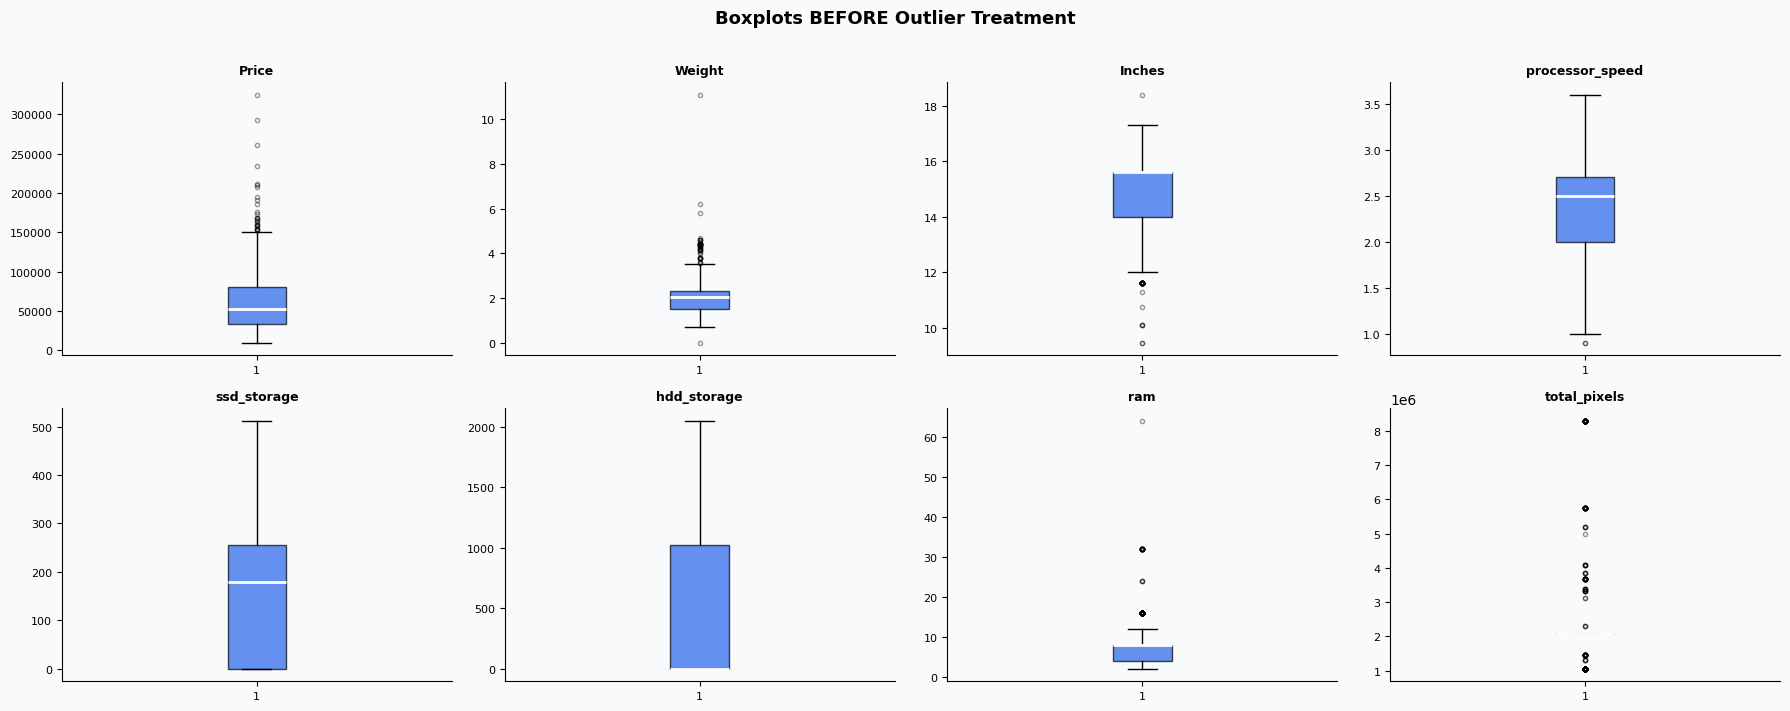

In [25]:
# ── Boxplots BEFORE treatment
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].boxplot(df_clean[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#2563EB', alpha=0.7),
                    medianprops=dict(color='white', lw=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#DC2626'))
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Boxplots BEFORE Outlier Treatment', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_before.png', dpi=120, bbox_inches='tight')
plt.show()


In [26]:
# ── Winsorize (cap) outliers at 1st and 99th percentile
df_processed = df_clean.copy()

def winsorize(df, col, lower_pct=0.01, upper_pct=0.99):
    lo = df[col].quantile(lower_pct)
    hi = df[col].quantile(upper_pct)
    df[col] = df[col].clip(lower=lo, upper=hi)
    return lo, hi

winsorize_cols = ['Price','Weight','processor_speed','total_pixels']
print("WINSORIZATION (1st–99th percentile)")
print("=" * 50)
for col in winsorize_cols:
    lo, hi = winsorize(df_processed, col)
    print(f"  {col:<22}: [{lo:.2f}, {hi:.2f}]")

print("\n✅ Outliers capped (winsorized)")


WINSORIZATION (1st–99th percentile)
  Price                 : [13053.29, 167933.23]
  Weight                : [0.97, 4.42]
  processor_speed       : [1.10, 3.00]
  total_pixels          : [1049088.00, 8294400.00]

✅ Outliers capped (winsorized)


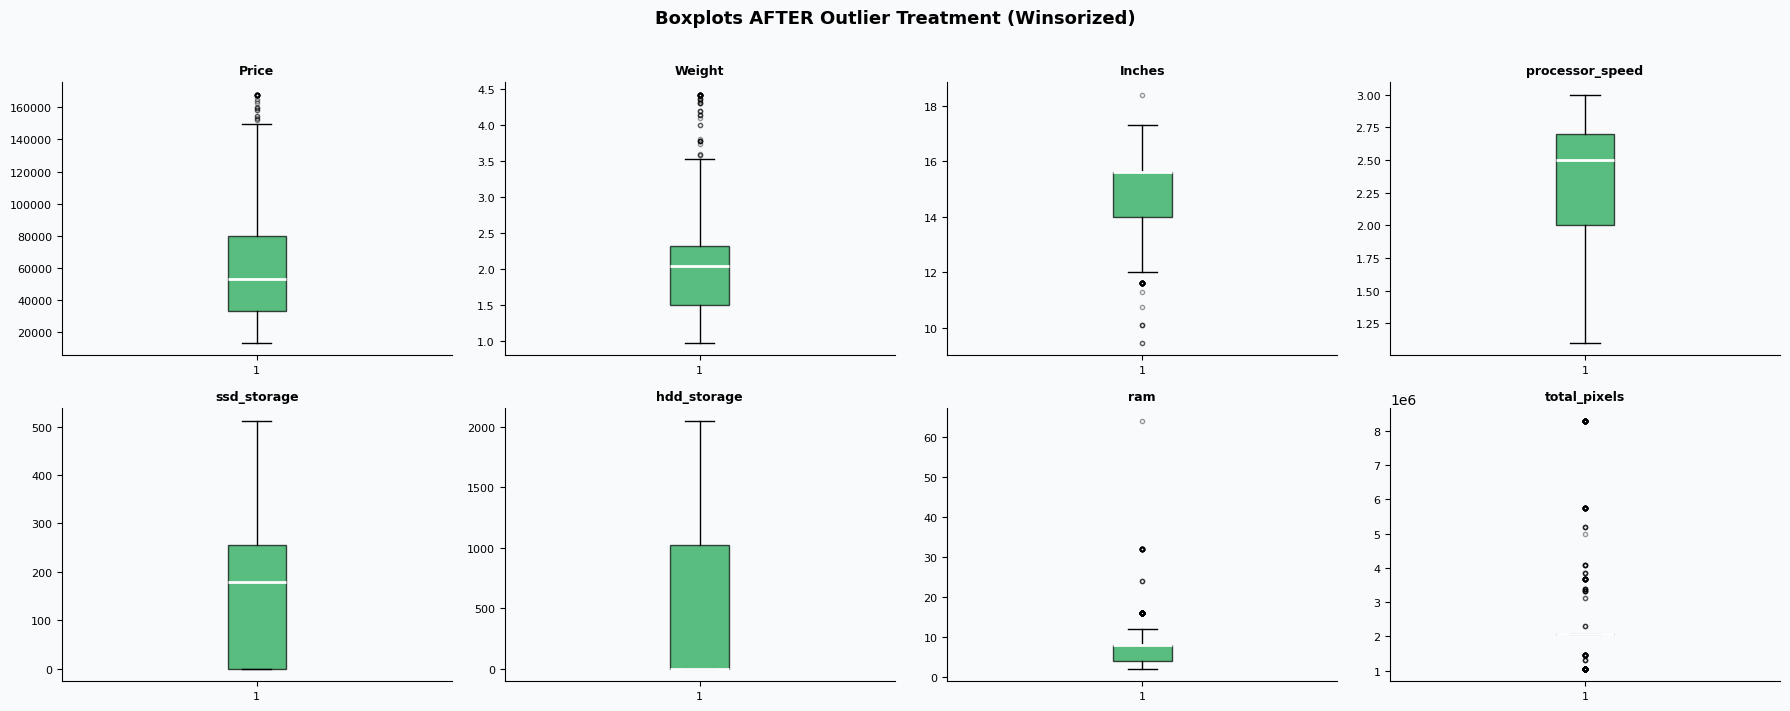

In [27]:
# ── Boxplots AFTER treatment
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].boxplot(df_processed[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#16A34A', alpha=0.7),
                    medianprops=dict(color='white', lw=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#D97706'))
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Boxplots AFTER Outlier Treatment (Winsorized)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('boxplots_after.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. ⚙️ Feature Engineering

Create new informative features from existing columns:
- `total_storage` = ssd + hdd + flash  
- `price_per_kg` = Price / Weight  
- `ppi` = pixels per inch (display sharpness)  
- `is_gaming` from TypeName  
- `is_premium_brand` (Apple/MSI/Razer)  
- `ram_to_storage_ratio`  
- `log_Price` (log-transform skewed target)


In [30]:
# ── New features
df_processed['total_storage']      = (df_processed['ssd_storage']
                                      + df_processed['hdd_storage']
                                      + df_processed['flash_storage'])

df_processed['price_per_kg']       = (df_processed['Price']
                                      / df_processed['Weight'].replace(0, np.nan)).fillna(0)

# PPI = sqrt(w²+h²) / Inches
df_processed['ppi']                = (
    np.sqrt(df_processed['res_width']**2 + df_processed['res_height']**2)
    / df_processed['Inches']
).round(1)

df_processed['is_gaming']          = (df_processed['TypeName'] == 'Gaming').astype(int)
df_processed['is_premium_brand']   = df_processed['Company'].isin(
                                        ['Apple','MSI','Razer']).astype(int)
df_processed['is_ultrabook']       = (df_processed['TypeName'] == 'Ultrabook').astype(int)

df_processed['ram_to_ssd_ratio']   = (
    df_processed['ram']
    / df_processed['ssd_storage'].replace(0, np.nan)
).fillna(0).round(4)

df_processed['log_Price']          = np.log1p(df_processed['Price'])
df_processed['log_ram']            = np.log1p(df_processed['ram'])

# cpu_bin ordinal encoding (already ordered)
bin_map = {'0.8-1.5':1,'1.5-2.0':2,'2.0-2.5':3,'2.5-3.0':4,'3.0-3.5':5,'3.5-4.0':6}
# df_processed['cpu_bin_ordinal']    = df_processed['cpu_bin'].astype(str).map(bin_map)

new_feats = ['total_storage','price_per_kg','ppi','is_gaming',
             'is_premium_brand','is_ultrabook','ram_to_ssd_ratio',
             'log_Price','log_ram']
print("✅ New features created:")
for f in new_feats:
    print(f"  + {f:<25} sample: {df_processed[f].head(3).values}")


✅ New features created:
  + total_storage             sample: [128 128 256]
  + price_per_kg              sample: [52101.22861314 35742.92776119 16470.96774194]
  + ppi                       sample: [227.  127.7 141.2]
  + is_gaming                 sample: [0 0 0]
  + is_premium_brand          sample: [1 1 0]
  + is_ultrabook              sample: [1 1 0]
  + ram_to_ssd_ratio          sample: [0.0625 0.     0.0312]
  + log_Price                 sample: [11.17576856 10.7767982  10.32996371]
  + log_ram                   sample: [2.19722458 2.19722458 2.19722458]


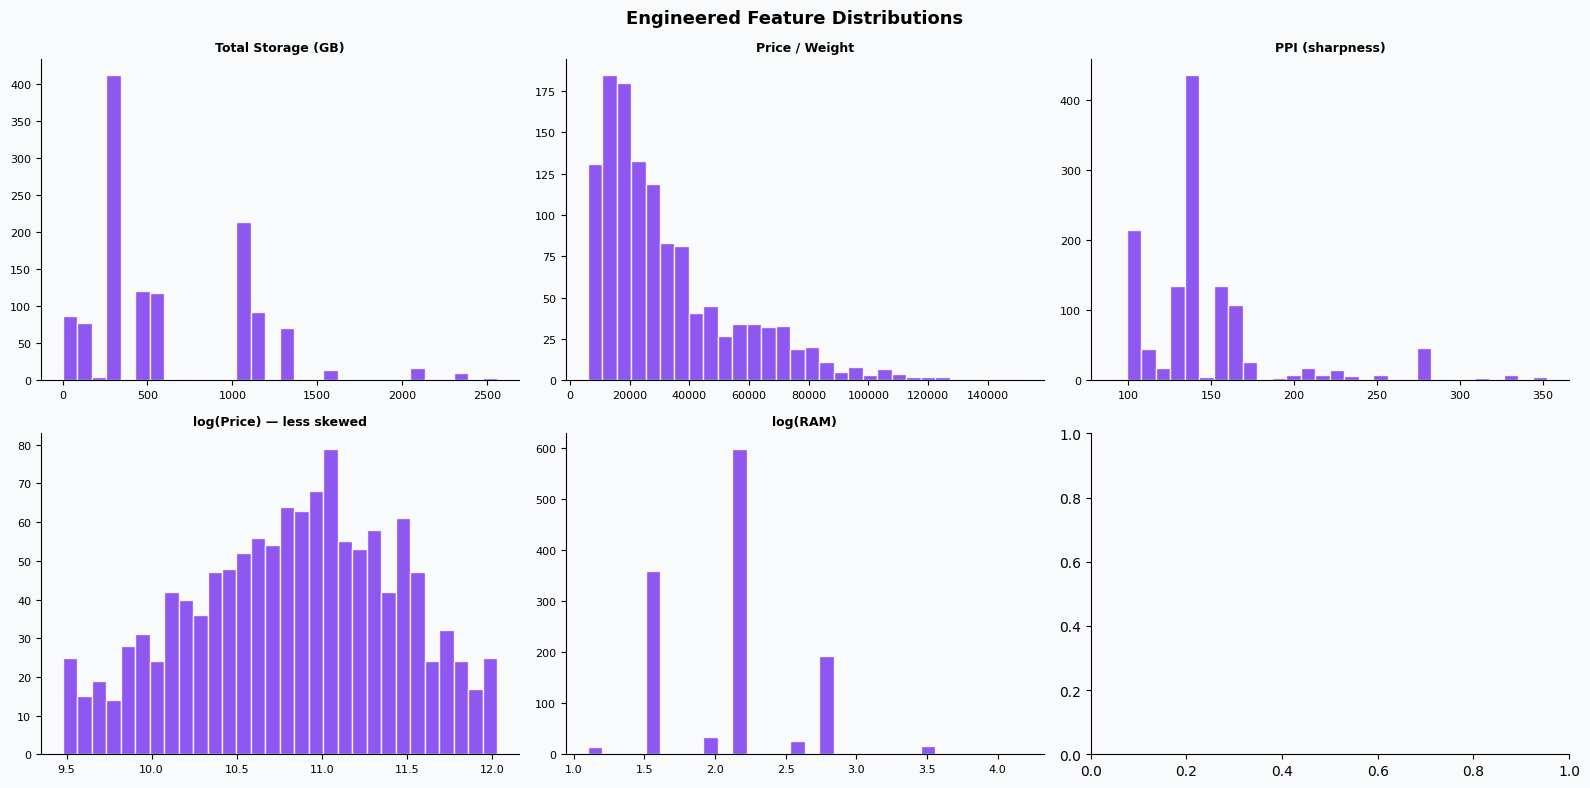

In [32]:
# ── Distribution of engineered numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

plot_feats = ['total_storage','price_per_kg','ppi','log_Price','log_ram','ppi']
titles     = ['Total Storage (GB)','Price per kg','PPI (pixel density)',
               'log(Price)','log(RAM)','PPI Distribution']

for i, (feat, title) in enumerate(zip(
        ['total_storage','price_per_kg','ppi','log_Price','log_ram','cpu_bin_ordinal'],
        ['Total Storage (GB)','Price / Weight','PPI (sharpness)',
         'log(Price) — less skewed','log(RAM)'])):
    axes[i].hist(df_processed[feat], bins=30, color='#7C3AED',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(title, fontweight='bold', fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Engineered Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('engineered_features.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. 🔢 Categorical Encoding

| Column | Strategy | Reason |
|---|---|---|
| `display_type` | Ordinal mapping | HD < Full HD < Quad HD < 4K |
| `processor_brand` | Label Encoding | Binary (Intel/AMD) |
| `os` | One-Hot Encoding | No natural order |
| `Company` | One-Hot Encoding | No natural order |
| `TypeName` | One-Hot Encoding | No natural order |
| `processor_type` | Label Encoding | Many categories |
| `screen_resolution` | Drop (already extracted) | |
| `cpu_bin` | Ordinal (already done) | |


In [33]:
df_encoded = df_processed.copy()

# ── 1. Ordinal encoding — display_type
display_order = {'HD': 1, 'Full HD': 2, 'Quad HD': 3, '4K': 4}
df_encoded['display_type_ord'] = df_encoded['display_type'].map(display_order)
print("display_type ordinal mapping:", display_order)

# ── 2. Label encoding — processor_brand, processor_type
le_brand = LabelEncoder()
le_ptype = LabelEncoder()
df_encoded['processor_brand_enc'] = le_brand.fit_transform(df_encoded['processor_brand'].astype(str))
df_encoded['processor_type_enc']  = le_ptype.fit_transform(df_encoded['processor_type'].astype(str))
print("\nprocessor_brand classes:", dict(zip(le_brand.classes_,
                                              le_brand.transform(le_brand.classes_))))
print("processor_type classes :", dict(zip(le_ptype.classes_,
                                            le_ptype.transform(le_ptype.classes_))))

# ── 3. One-Hot encoding — os, Company, TypeName
ohe_cols = ['os', 'Company', 'TypeName']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, prefix=ohe_cols,
                             drop_first=True, dtype=int)
print(f"\nAfter OHE, shape: {df_encoded.shape}")
print("New OHE columns:", [c for c in df_encoded.columns
                            if any(c.startswith(p) for p in ohe_cols)])


display_type ordinal mapping: {'HD': 1, 'Full HD': 2, 'Quad HD': 3, '4K': 4}

processor_brand classes: {'AMD': np.int64(0), 'Intel': np.int64(1), 'Samsung': np.int64(2)}
processor_type classes : {' A10-Series 9600P': np.int64(0), ' A10-Series 9620P': np.int64(1), ' A10-Series A10-9620P': np.int64(2), ' A12-Series 9700P': np.int64(3), ' A12-Series 9720P': np.int64(4), ' A4-Series 7210': np.int64(5), ' A6-Series 7310': np.int64(6), ' A6-Series 9220': np.int64(7), ' A6-Series A6-9220': np.int64(8), ' A8-Series 7410': np.int64(9), ' A9-Series 9410': np.int64(10), ' A9-Series 9420': np.int64(11), ' A9-Series A9-9420': np.int64(12), ' Atom X5-Z8350': np.int64(13), ' Atom Z8350': np.int64(14), ' Atom x5-Z8300': np.int64(15), ' Atom x5-Z8350': np.int64(16), ' Atom x5-Z8550': np.int64(17), ' Celeron Dual Core 3205U': np.int64(18), ' Celeron Dual Core 3855U': np.int64(19), ' Celeron Dual Core N3050': np.int64(20), ' Celeron Dual Core N3060': np.int64(21), ' Celeron Dual Core N3350': np.int64(22)

In [34]:
# ── Drop redundant / raw columns no longer needed
drop_raw = ['screen_resolution', 'display_type', 'processor_brand',
            'processor_type', 'cpu_bin']

df_encoded.drop(columns=[c for c in drop_raw if c in df_encoded.columns], inplace=True)
print(f"Dropped raw columns: {drop_raw}")
print(f"\nShape after encoding: {df_encoded.shape}")
print("\nAll columns:")
print(list(df_encoded.columns))


Dropped raw columns: ['screen_resolution', 'display_type', 'processor_brand', 'processor_type', 'cpu_bin']

Shape after encoding: (1243, 49)

All columns:
['Inches', 'Weight', 'processor_speed', 'ssd_storage', 'hdd_storage', 'flash_storage', 'ram', 'Price', 'res_width', 'res_height', 'total_pixels', 'total_storage', 'price_per_kg', 'ppi', 'is_gaming', 'is_premium_brand', 'is_ultrabook', 'ram_to_ssd_ratio', 'log_Price', 'log_ram', 'display_type_ord', 'processor_brand_enc', 'processor_type_enc', 'os_linux', 'os_mac', 'os_macos', 'os_no', 'os_windows', 'Company_Apple', 'Company_Asus', 'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu', 'Company_Google', 'Company_HP', 'Company_Huawei', 'Company_LG', 'Company_Lenovo', 'Company_MSI', 'Company_Mediacom', 'Company_Microsoft', 'Company_Razer', 'Company_Samsung', 'Company_Toshiba', 'Company_Xiaomi', 'TypeName_Gaming', 'TypeName_Notebook', 'TypeName_Ultrabook', 'TypeName_Workstation']


## 8. 📏 Feature Scaling

Three scalers compared — choose based on model:
- **StandardScaler** → mean=0, std=1 (good for linear models, SVM)
- **MinMaxScaler**   → [0,1] range (good for neural nets, KNN)
- **RobustScaler**   → median/IQR-based (good when outliers remain)


In [35]:
# ── Define feature matrix X and target y
TARGET    = 'Price'       # original price
LOG_TARGET= 'log_Price'   # log-transformed target

# Drop both target forms and any leakage columns from features
EXCLUDE   = [TARGET, LOG_TARGET, 'price_per_kg',  # price_per_kg derived from Price
             'res_width', 'res_height']            # redundant after total_pixels

feature_cols = [c for c in df_encoded.select_dtypes(include='number').columns
                if c not in EXCLUDE]

X = df_encoded[feature_cols].copy()
y = df_encoded[TARGET].copy()

print(f"Feature matrix X: {X.shape}")
print(f"Target y (Price): {y.shape}")
print(f"\nFeature columns ({len(feature_cols)}):")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {c}")


Feature matrix X: (1243, 44)
Target y (Price): (1243,)

Feature columns (44):
   1. Inches
   2. Weight
   3. processor_speed
   4. ssd_storage
   5. hdd_storage
   6. flash_storage
   7. ram
   8. total_pixels
   9. total_storage
  10. ppi
  11. is_gaming
  12. is_premium_brand
  13. is_ultrabook
  14. ram_to_ssd_ratio
  15. log_ram
  16. display_type_ord
  17. processor_brand_enc
  18. processor_type_enc
  19. os_linux
  20. os_mac
  21. os_macos
  22. os_no
  23. os_windows
  24. Company_Apple
  25. Company_Asus
  26. Company_Chuwi
  27. Company_Dell
  28. Company_Fujitsu
  29. Company_Google
  30. Company_HP
  31. Company_Huawei
  32. Company_LG
  33. Company_Lenovo
  34. Company_MSI
  35. Company_Mediacom
  36. Company_Microsoft
  37. Company_Razer
  38. Company_Samsung
  39. Company_Toshiba
  40. Company_Xiaomi
  41. TypeName_Gaming
  42. TypeName_Notebook
  43. TypeName_Ultrabook
  44. TypeName_Workstation


In [36]:
# ── Apply all 3 scalers for comparison
cols_to_scale = ['Inches','Weight','processor_speed','ssd_storage','hdd_storage',
                 'flash_storage','ram','total_pixels','ppi','total_storage',
                 'log_ram','cpu_bin_ordinal']
cols_to_scale = [c for c in cols_to_scale if c in X.columns]

standard_scaler = StandardScaler()
minmax_scaler   = MinMaxScaler()
robust_scaler   = RobustScaler()

X_standard = X.copy()
X_minmax   = X.copy()
X_robust   = X.copy()

X_standard[cols_to_scale] = standard_scaler.fit_transform(X[cols_to_scale])
X_minmax[cols_to_scale]   = minmax_scaler.fit_transform(X[cols_to_scale])
X_robust[cols_to_scale]   = robust_scaler.fit_transform(X[cols_to_scale])

print("✅ Scaling applied:")
print("  StandardScaler → mean≈0, std≈1")
print("  MinMaxScaler   → range [0, 1]")
print("  RobustScaler   → median/IQR based")

# Show comparison for 'Weight'
print("\nSample comparison for 'Weight':")
print(f"  Original  : {X['Weight'].describe()[['mean','std','min','max']].round(2).to_dict()}")
print(f"  Standard  : {X_standard['Weight'].describe()[['mean','std','min','max']].round(2).to_dict()}")
print(f"  MinMax    : {X_minmax['Weight'].describe()[['mean','std','min','max']].round(2).to_dict()}")
print(f"  Robust    : {X_robust['Weight'].describe()[['mean','std','min','max']].round(2).to_dict()}")


✅ Scaling applied:
  StandardScaler → mean≈0, std≈1
  MinMaxScaler   → range [0, 1]
  RobustScaler   → median/IQR based

Sample comparison for 'Weight':
  Original  : {'mean': 2.05, 'std': 0.68, 'min': 0.97, 'max': 4.42}
  Standard  : {'mean': 0.0, 'std': 1.0, 'min': -1.59, 'max': 3.49}
  MinMax    : {'mean': 0.31, 'std': 0.2, 'min': 0.0, 'max': 1.0}
  Robust    : {'mean': 0.02, 'std': 0.83, 'min': -1.3, 'max': 2.9}


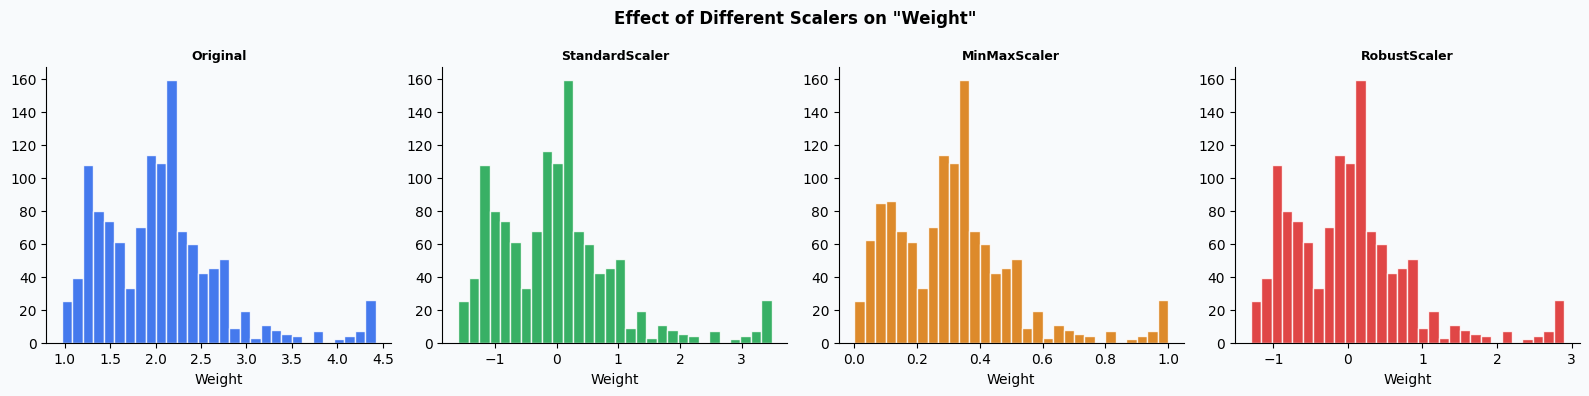


✅ X_scaled = StandardScaler version selected for pipeline


In [37]:
# ── Visualise scaling effect
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
compare_col = 'Weight'
for ax, (data, title, color) in zip(axes, [
    (X,          'Original',       '#2563EB'),
    (X_standard, 'StandardScaler', '#16A34A'),
    (X_minmax,   'MinMaxScaler',   '#D97706'),
    (X_robust,   'RobustScaler',   '#DC2626'),
]):
    ax.hist(data[compare_col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xlabel(compare_col)

plt.suptitle('Effect of Different Scalers on "Weight"', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

# Use StandardScaler as default going forward
X_scaled = X_standard.copy()
print("\n✅ X_scaled = StandardScaler version selected for pipeline")


## 9. 🎯 Feature Selection

Three approaches:
1. **Correlation** with target (filter method)  
2. **SelectKBest** with f_regression (statistical)  
3. **Mutual Information** (non-linear relationships)  

Drop features with |corr| < 0.05 and low MI scores.


In [38]:
# ── Correlation with Price
corr_with_target = X_scaled.corrwith(y).abs().sort_values(ascending=False)

print("CORRELATION WITH PRICE (absolute value)")
print("=" * 45)
print(corr_with_target.round(4).to_string())


CORRELATION WITH PRICE (absolute value)
log_ram                0.75
ram                    0.72
TypeName_Notebook      0.61
display_type_ord       0.59
ssd_storage            0.59
total_pixels           0.50
ppi                    0.48
processor_type_enc     0.48
processor_speed        0.44
is_gaming              0.38
TypeName_Gaming        0.38
ram_to_ssd_ratio       0.32
is_ultrabook           0.28
TypeName_Ultrabook     0.28
TypeName_Workstation   0.25
is_premium_brand       0.25
os_windows             0.24
Weight                 0.20
Company_MSI            0.19
processor_brand_enc    0.19
os_no                  0.19
os_linux               0.17
Company_Razer          0.16
os_macos               0.10
Company_Mediacom       0.09
hdd_storage            0.09
total_storage          0.09
Company_Apple          0.09
Company_LG             0.07
Company_Chuwi          0.06
Company_Dell           0.06
Company_Microsoft      0.05
Company_Google         0.04
Company_HP             0.04
Company_

In [39]:
# ── SelectKBest (f_regression)
k = min(15, X_scaled.shape[1])
selector_f = SelectKBest(score_func=f_regression, k=k)
selector_f.fit(X_scaled, y)

f_scores = pd.Series(selector_f.scores_, index=X_scaled.columns).sort_values(ascending=False)
print(f"TOP {k} FEATURES — F-Regression Scores")
print("=" * 45)
print(f_scores.round(2).to_string())


TOP 15 FEATURES — F-Regression Scores
log_ram                1616.53
ram                    1352.73
TypeName_Notebook       720.43
display_type_ord        665.63
ssd_storage             646.91
total_pixels            423.30
ppi                     378.45
processor_type_enc      371.95
processor_speed         302.47
is_gaming               203.97
TypeName_Gaming         203.97
ram_to_ssd_ratio        136.74
is_ultrabook            105.62
TypeName_Ultrabook      105.62
TypeName_Workstation     84.17
is_premium_brand         82.43
os_windows               78.45
Weight                   49.41
Company_MSI              46.53
processor_brand_enc      45.90
os_no                    44.21
os_linux                 35.96
Company_Razer            32.99
os_macos                 11.72
Company_Mediacom         11.28
hdd_storage              10.74
total_storage            10.60
Company_Apple             9.36
Company_LG                6.52
Company_Chuwi             4.58
Company_Dell              3.93
C

In [40]:
# ── Mutual Information
selector_mi = SelectKBest(score_func=mutual_info_regression, k=k)
selector_mi.fit(X_scaled, y)

mi_scores = pd.Series(selector_mi.scores_, index=X_scaled.columns).sort_values(ascending=False)
print(f"TOP {k} FEATURES — Mutual Information Scores")
print("=" * 45)
print(mi_scores.round(4).to_string())


TOP 15 FEATURES — Mutual Information Scores
processor_type_enc     0.66
log_ram                0.51
ram                    0.50
processor_speed        0.47
total_storage          0.42
ppi                    0.41
ssd_storage            0.30
Weight                 0.29
total_pixels           0.28
ram_to_ssd_ratio       0.27
TypeName_Notebook      0.26
display_type_ord       0.25
Inches                 0.20
is_gaming              0.09
flash_storage          0.08
is_ultrabook           0.08
TypeName_Ultrabook     0.08
TypeName_Gaming        0.08
hdd_storage            0.07
os_windows             0.07
os_linux               0.04
TypeName_Workstation   0.04
is_premium_brand       0.02
os_no                  0.02
processor_brand_enc    0.02
Company_MSI            0.02
Company_Razer          0.02
Company_Lenovo         0.02
Company_Apple          0.01
Company_Dell           0.01
Company_Microsoft      0.01
Company_LG             0.01
Company_Mediacom       0.01
Company_Fujitsu        0.01
Comp

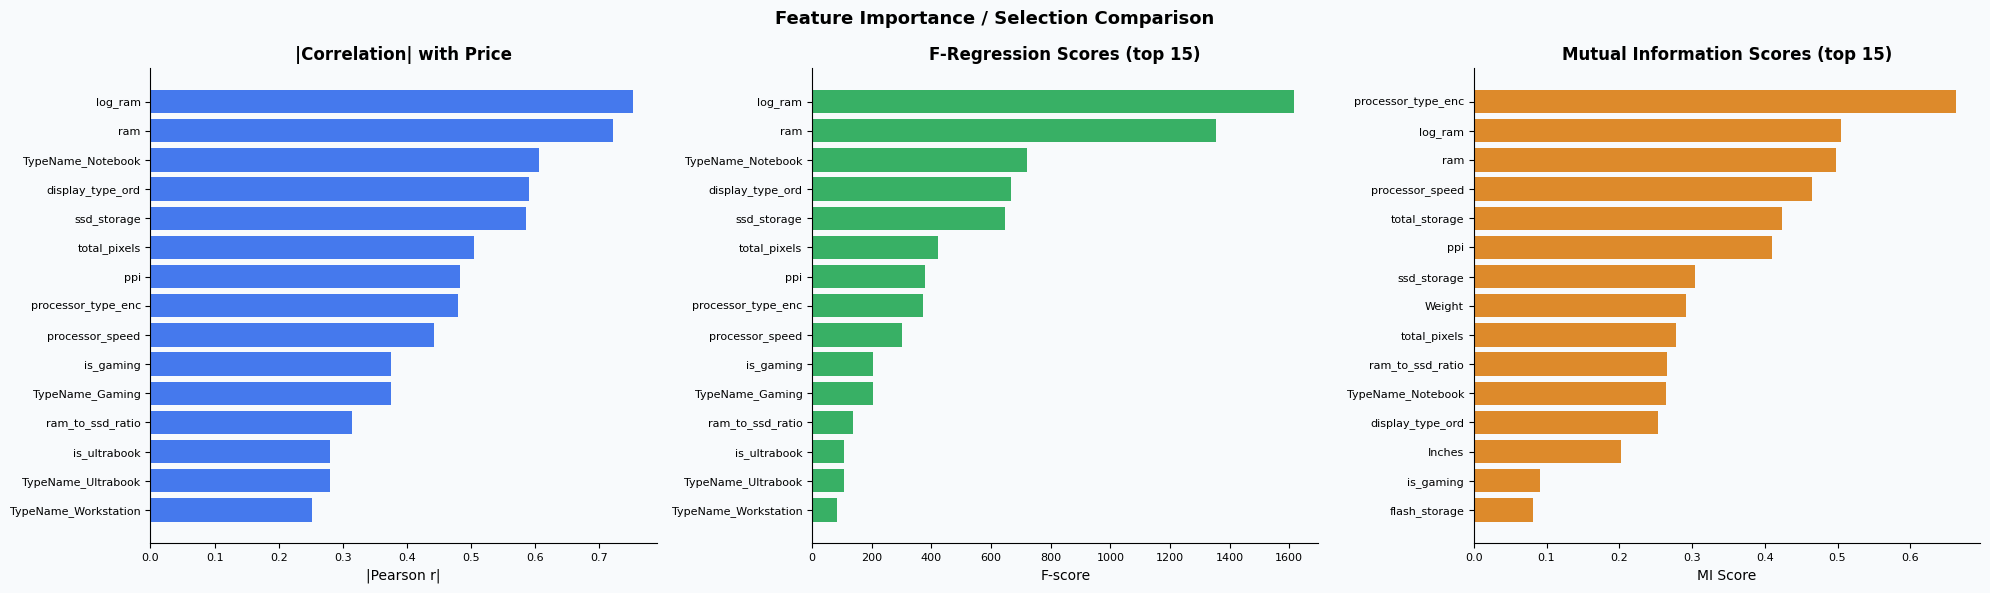

In [41]:
# ── Feature importance summary plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Correlation
top_corr = corr_with_target.head(15)
axes[0].barh(top_corr.index[::-1], top_corr.values[::-1], color='#2563EB', alpha=0.85)
axes[0].set_title('|Correlation| with Price', fontweight='bold')
axes[0].set_xlabel('|Pearson r|')

# F-score
top_f = f_scores.head(15)
axes[1].barh(top_f.index[::-1], top_f.values[::-1], color='#16A34A', alpha=0.85)
axes[1].set_title('F-Regression Scores (top 15)', fontweight='bold')
axes[1].set_xlabel('F-score')

# MI score
top_mi = mi_scores.head(15)
axes[2].barh(top_mi.index[::-1], top_mi.values[::-1], color='#D97706', alpha=0.85)
axes[2].set_title('Mutual Information Scores (top 15)', fontweight='bold')
axes[2].set_xlabel('MI Score')

for ax in axes:
    ax.tick_params(labelsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Feature Importance / Selection Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection.png', dpi=120, bbox_inches='tight')
plt.show()


In [42]:
# ── Select final features (top 12 by MI score)
N_FEATURES        = 12
selected_features = mi_scores.head(N_FEATURES).index.tolist()

X_selected = X_scaled[selected_features].copy()
print(f"✅ Selected top {N_FEATURES} features (by Mutual Information):")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:>2}. {f}")
print(f"\nX_selected shape: {X_selected.shape}")


✅ Selected top 12 features (by Mutual Information):
   1. processor_type_enc
   2. log_ram
   3. ram
   4. processor_speed
   5. total_storage
   6. ppi
   7. ssd_storage
   8. Weight
   9. total_pixels
  10. ram_to_ssd_ratio
  11. TypeName_Notebook
  12. display_type_ord

X_selected shape: (1243, 12)


## 10. ✂️ Train / Validation / Test Split

Split strategy: **70% train | 15% validation | 15% test** (stratified not needed for regression)


In [43]:
# ── Step 1: 70/30 split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_selected, y, test_size=0.30, random_state=42
)

# ── Step 2: Split the 30% into 50/50 → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42
)

print("TRAIN / VAL / TEST SPLIT")
print("=" * 40)
print(f"  Training   : {X_train_full.shape[0]:>5} rows ({X_train_full.shape[0]/len(X_selected)*100:.1f}%)")
print(f"  Validation : {X_val.shape[0]:>5} rows ({X_val.shape[0]/len(X_selected)*100:.1f}%)")
print(f"  Test       : {X_test.shape[0]:>5} rows ({X_test.shape[0]/len(X_selected)*100:.1f}%)")
print(f"  Features   : {X_train_full.shape[1]}")
print(f"\n  Train Price mean : ₹{y_train_full.mean():,.0f}")
print(f"  Val   Price mean : ₹{y_val.mean():,.0f}")
print(f"  Test  Price mean : ₹{y_test.mean():,.0f}")


TRAIN / VAL / TEST SPLIT
  Training   :   870 rows (70.0%)
  Validation :   186 rows (15.0%)
  Test       :   187 rows (15.0%)
  Features   : 12

  Train Price mean : ₹60,196
  Val   Price mean : ₹57,335
  Test  Price mean : ₹62,591


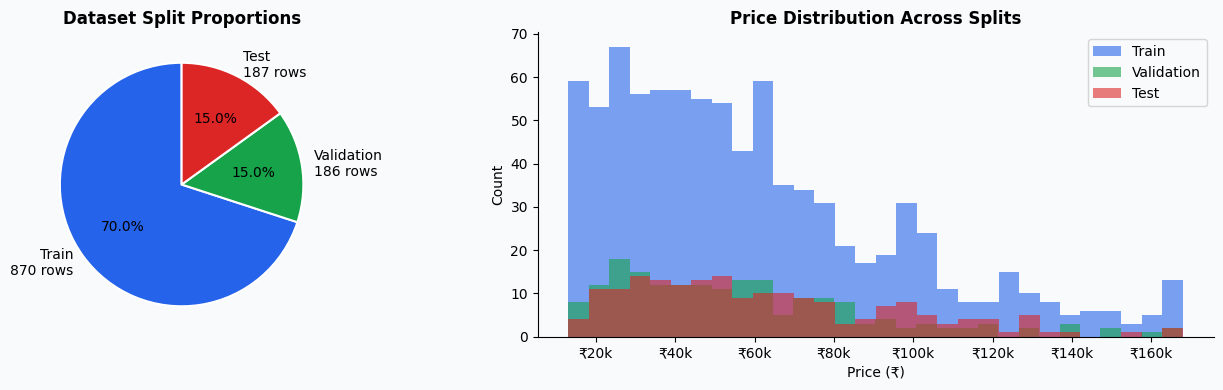

In [44]:
# ── Visualise split proportions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pie chart
sizes  = [len(X_train_full), len(X_val), len(X_test)]
labels = [f'Train\n{sizes[0]} rows', f'Validation\n{sizes[1]} rows', f'Test\n{sizes[2]} rows']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=['#2563EB','#16A34A','#DC2626'],
            startangle=90, wedgeprops=dict(edgecolor='white', lw=1.5))
axes[0].set_title('Dataset Split Proportions', fontweight='bold')

# Price distribution across splits
axes[1].hist(y_train_full, bins=30, alpha=0.6, color='#2563EB', label='Train')
axes[1].hist(y_val,        bins=30, alpha=0.6, color='#16A34A', label='Validation')
axes[1].hist(y_test,       bins=30, alpha=0.6, color='#DC2626', label='Test')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}k'))
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price Distribution Across Splits', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. 📋 Final Summary & Export

Save all preprocessed splits to CSV files ready for modelling.


In [45]:
# ── Final preprocessed data summary
print("=" * 60)
print("  PREPROCESSING PIPELINE — FINAL SUMMARY")
print("=" * 60)

steps = [
    ("1. Libraries",          "pandas, numpy, sklearn, scipy, matplotlib, seaborn"),
    ("2. Data Loaded",        f"{df.shape[0]} rows × {df.shape[1]} cols"),
    ("3. Missing Values",     "Median (numeric) + Mode (categorical) imputation"),
    ("4. Data Types",         "bool→int, category ordered, screen_res parsed"),
    ("5. Outliers",           "Winsorized at 1st–99th percentile"),
    ("6. Feature Eng.",       "+10 new features (ppi, log_Price, is_gaming, ...)"),
    ("7. Encoding",           "Ordinal + Label + One-Hot (OHE)"),
    ("8. Scaling",            "StandardScaler (default) | MinMax | Robust available"),
    ("9. Feature Selection",  f"Top {N_FEATURES} by Mutual Information"),
    ("10. Split",             f"Train {len(X_train_full)} | Val {len(X_val)} | Test {len(X_test)}"),
]

for step, detail in steps:
    print(f"  {step:<25} → {detail}")

print(f"\n  Final feature set ({len(selected_features)}):")
for f in selected_features:
    print(f"    • {f}")


  PREPROCESSING PIPELINE — FINAL SUMMARY
  1. Libraries              → pandas, numpy, sklearn, scipy, matplotlib, seaborn
  2. Data Loaded            → 1243 rows × 15 cols
  3. Missing Values         → Median (numeric) + Mode (categorical) imputation
  4. Data Types             → bool→int, category ordered, screen_res parsed
  5. Outliers               → Winsorized at 1st–99th percentile
  6. Feature Eng.           → +10 new features (ppi, log_Price, is_gaming, ...)
  7. Encoding               → Ordinal + Label + One-Hot (OHE)
  8. Scaling                → StandardScaler (default) | MinMax | Robust available
  9. Feature Selection      → Top 12 by Mutual Information
  10. Split                 → Train 870 | Val 186 | Test 187

  Final feature set (12):
    • processor_type_enc
    • log_ram
    • ram
    • processor_speed
    • total_storage
    • ppi
    • ssd_storage
    • Weight
    • total_pixels
    • ram_to_ssd_ratio
    • TypeName_Notebook
    • display_type_ord


In [46]:
# ── Export preprocessed files
import os
os.makedirs('preprocessed_data', exist_ok=True)

# Full preprocessed dataframe
df_processed.to_csv('preprocessed_data/laptop_preprocessed_full.csv', index=False)

# Train / Val / Test splits (features + target together)
train_export = X_train_full.copy(); train_export['Price'] = y_train_full.values
val_export   = X_val.copy();        val_export['Price']   = y_val.values
test_export  = X_test.copy();       test_export['Price']  = y_test.values

train_export.to_csv('preprocessed_data/train.csv',      index=False)
val_export.to_csv('preprocessed_data/validation.csv',   index=False)
test_export.to_csv('preprocessed_data/test.csv',        index=False)

print("✅ Files saved to /preprocessed_data/:")
print("   laptop_preprocessed_full.csv")
print("   train.csv")
print("   validation.csv")
print("   test.csv")


✅ Files saved to /preprocessed_data/:
   laptop_preprocessed_full.csv
   train.csv
   validation.csv
   test.csv


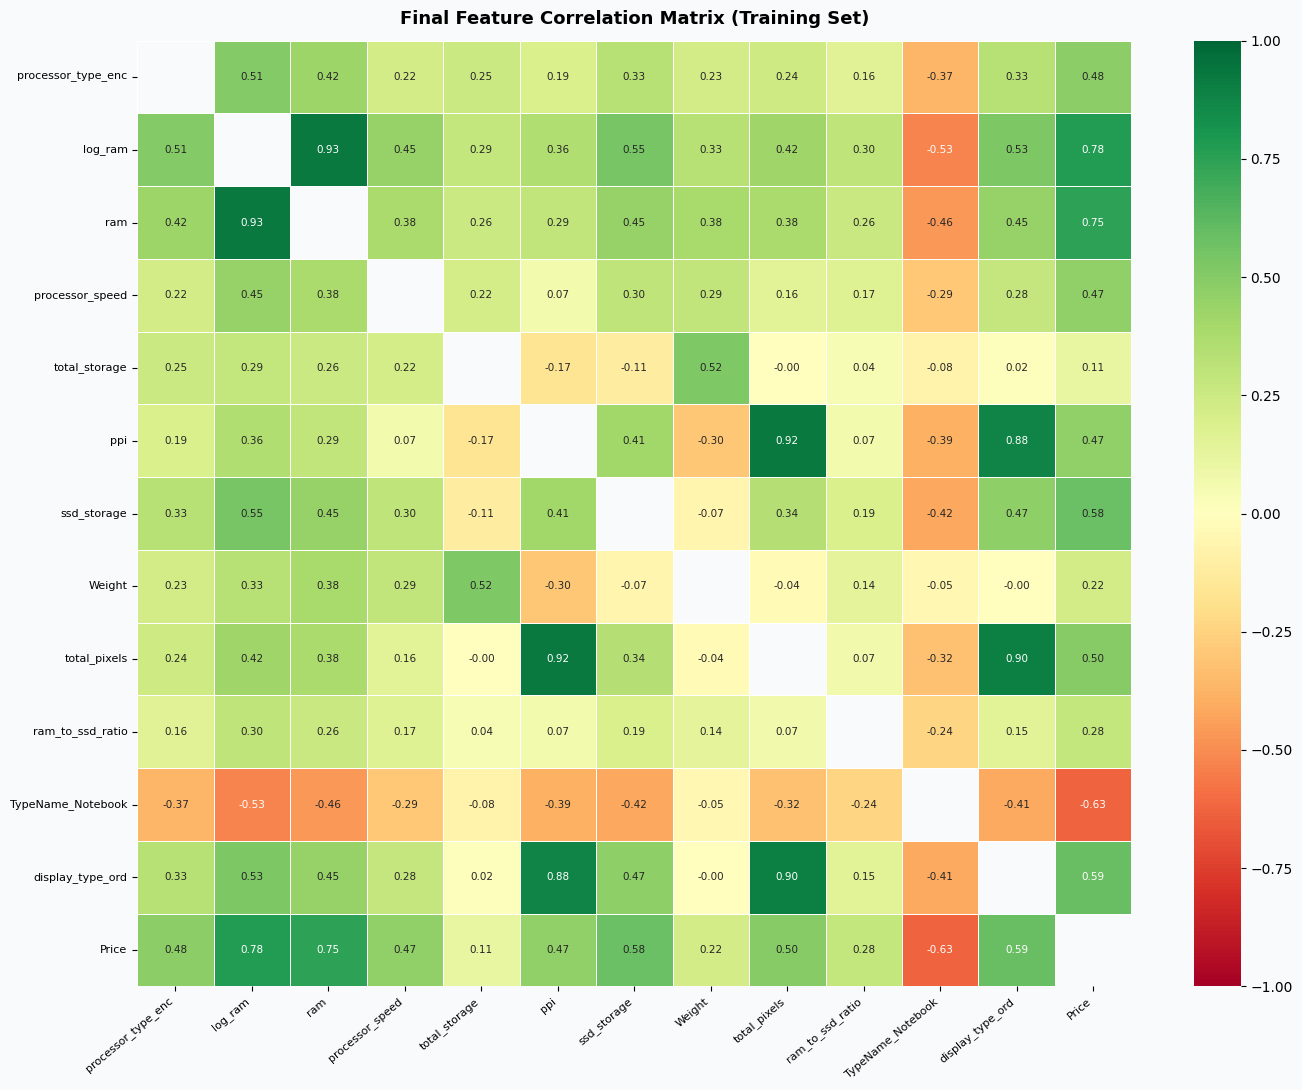

✅ Final correlation heatmap saved


In [47]:
# ── Final correlation heatmap (selected features vs Price)
corr_data = X_train_full.copy()
corr_data['Price'] = y_train_full.values
corr_matrix = corr_data.corr()

plt.figure(figsize=(14, 11))
mask = np.zeros_like(corr_matrix, dtype=bool)
np.fill_diagonal(mask, True)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.4,
            annot_kws={'size': 7.5}, mask=mask)
plt.title('Final Feature Correlation Matrix (Training Set)',
          fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('preprocessed_data/final_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Final correlation heatmap saved")


In [48]:
print("=" * 60)
print("  PREPROCESSING COMPLETE - READY FOR MODELLING!")
print("=" * 60)
print(f"Train: {X_train_full.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Features: {len(selected_features)}")
print("Recommended: LinearRegression, RandomForest, XGBoost")


  PREPROCESSING COMPLETE - READY FOR MODELLING!
Train: (870, 12) | Val: (186, 12) | Test: (187, 12)
Features: 12
Recommended: LinearRegression, RandomForest, XGBoost
